
# Kling–Gupta efficiency (KGE)

In this notebook, we will explore the Kling-Gupta Efficiency (KGE) and Nash-Sutcliffe Efficiency (NSE) metrics, 
which are widely used to evaluate the performance of hydrological models. We'll see how KGE can provide a more 
comprehensive assessment compared to NSE.

## Overview
- **NSE**: Measures the relative magnitude of residual variance compared to the variance of the observed data.
- **KGE**: A metric that decomposes NSE into three components (correlation, bias, and variability).



## Equations

### Nash-Sutcliffe Efficiency (NSE)
\[
NSE = 1 - \frac{\sum_{i=1}^{n} (Q_{obs,i} - Q_{sim,i})^2}{\sum_{i=1}^{n} (Q_{obs,i} - \bar{Q}_{obs})^2}
\]
- \( Q_{obs} \) are observed values.
- \( Q_{sim} \) are simulated values.
- \( \bar{Q}_{obs} \) is the mean of observed values.

### Kling-Gupta Efficiency (KGE)
\[
KGE = 1 - \sqrt{(r-1)^2 + (\beta-1)^2 + (\gamma-1)^2}
\]
- \( r \): Linear correlation between observed and simulated values.
- \( \beta \): Bias ratio (mean of simulated / mean of observed).
- \( \gamma \): Variability ratio (coefficient of variation of simulated / coefficient of variation of observed).



## References
- Gupta, H. V., Kling, H., Yilmaz, K. K., & Martinez, G. F. (2009). Decomposition of the mean squared error and NSE performance criteria: Implications for improving hydrological modeling. *Journal of Hydrology*, 377(1-2), 80-91.
- Nash, J. E., & Sutcliffe, J. V. (1970). River flow forecasting through conceptual models part I—A discussion of principles. *Journal of Hydrology*, 10(3), 282-290.


In [1]:
from scores.continuous import multiplicative_bias
from scores.continuous.correlation import pearsonr
from scores.continuous import kge

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import xarray as xr

np.random.seed(42)  # Ensures consistent values across notebook runs

In [2]:
# Uncomment the line below to view detailed help information on the arguments to the kge function
# help(kge)

We used the same synthetic data generated for tutorial of [Pearson's correlation coefficient](Pearsons_Correlation.ipynb) and analysis done in that tutorial is very relevant to understand KGE. But instead of mean squarred error (mse), we compute multiplicative bias. So we will recap the analysis done there.

Two set of synthetic forecasts are generated:
- Forecast system 1 is identical to the observations but has a constant bias introduced.
- Forecast system 2 predicts random values around a mean value close to that of the observations.

In [3]:
obs = 10 * np.random.random((50, 50))  # Generate obs sample with mean of about 5.0
obs = xr.DataArray(
    data=obs, 
    dims=["time", "x"],
    coords={"time": pd.date_range("2023-01-01", "2023-02-19"), "x": np.arange(0, 50)}
)

# Create forecasts
fcst1 = obs - 4      # Generate Forecast system 1 with with mean of about 1.0

fcst2 = 4.5 + np.random.random((50, 50))  # Generate Forecast system 2 with with mean of about 5.0
fcst2 = xr.DataArray(
    data=fcst2, 
    dims=["time", "x"],
    coords={"time": pd.date_range("2023-01-01", "2023-02-19"), "x": np.arange(0, 50)}
)

In [4]:
obs.mean()

<xarray.DataArray ()> Size: 8B
array(4.98878265)

In [5]:
fcst1.mean()

<xarray.DataArray ()> Size: 8B
array(0.98878265)

In [6]:
fcst2.mean()

<xarray.DataArray ()> Size: 8B
array(4.99478572)

Let us repeoduce figures from [Pearson's correlation coefficient](Pearsons_Correlation.ipynb).

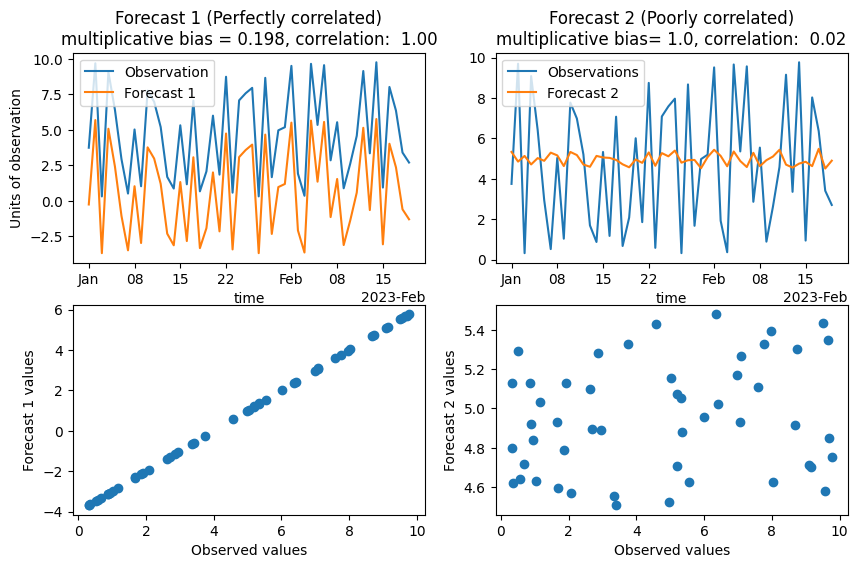

In [7]:
# Let's view a time series of both forecasts and observations for a single point
fig,axs = plt.subplots(2,2,figsize=(10,6))
obs.sel(x=0).drop_vars(["x"]).plot(ax=axs[0,0],label='Observation')
fcst1.sel(x=0).drop_vars(["x"]).plot(ax=axs[0,0],label='Forecast 1')
axs[0,0].set_ylabel("Units of observation")
axs[0,0].legend()

obs.sel(x=0).drop_vars(["x"]).plot(ax=axs[0,1],label='Observations')
fcst2.sel(x=0).drop_vars(["x"]).plot(ax=axs[0,1],label='Forecast 2')
axs[0,1].legend()

# scatter plot
axs[1,0].scatter(obs.sel(x=0).values, fcst1.sel(x=0).values)
axs[1,0].set_ylabel("Forecast 1 values")
axs[1,0].set_xlabel("Observed values")

axs[1,1].scatter(obs.sel(x=0).values, fcst2.sel(x=0).values)
axs[1,1].set_ylabel("Forecast 2 values")
axs[1,1].set_xlabel("Observed values");

# let's calculate the bias and correlation of each forecast system
bias1 = multiplicative_bias(fcst1, obs).item()
bias2 = multiplicative_bias(fcst2, obs).item()

corr1 = pearsonr(fcst1, obs).item()
corr2 = pearsonr(fcst2, obs).item()

axs[0,0].set_title(f"Forecast 1 (Perfectly correlated)\nmultiplicative bias = {bias1:.3}, correlation:  {corr1:.2f}")
axs[0,1].set_title(f"Forecast 2 (Poorly correlated)\nmultiplicative bias= {bias2:.3}, correlation:  {corr2:.2f}");

plt.show()

Recap from  [Pearson's correlation coefficient](Pearsons_Correlation.ipynb):
- Forecast system 1 is significantly underestimating the observations, producing predictions that are about 20% (multiplicative bias = 0.198) of the observed values on average. However, there is a close relationship between forecast 1 and observation data (Pearson correlation value = 1.0 )
- On average predictions from forecast system 2 are perferctly aigined with the observed values (multiplicative bias = 1.0). However there is no correlation between the observation and forecast (Pearson correlation value = 0.02)

Let us calculate KGE and its component values for both forecast systems.

In [8]:
#Let's calculate the KGE of each forecast system
kge1,kge1_r,kge1_alpha,kge1_beta = kge(fcst1, obs,return_components=True)
kge2,kge2_r,kge2_alpha,kge2_beta = kge(fcst2, obs,return_components=True)
print(f"Forecast system 1: KGE = {kge1.item():.3}, correlation(r) = {kge1_r.item():.3}, variability(alpha) = {kge1_alpha.item():.3}, bias(beta) = {kge1_beta.item():.3}")
print(f"Forecast system 2: KGE = {kge2.item():.3}, correlation(r) = {kge2_r.item():.3}, variability(alpha) = {kge2_alpha.item():.3}, bias(beta) = {kge2_beta.item():.3}")

Forecast system 1: KGE = 0.198, correlation(r) = 1.0, variability(alpha) = 1.0, bias(beta) = 0.198
Forecast system 2: KGE = -0.329, correlation(r) = 0.0236, variability(alpha) = 0.0992, bias(beta) = 1.0


Forecast system 1 performs better in terms of KGE, with a KGE score of 0.198. It has a perfect correlation (r = 1.0) and perfect variability (alpha = 1.0), but the bias component (beta = 0.198) indicates a significant underestimation of the observations. Despite the bias, the strong correlation and variability lead to a higher KGE score.

On the other hand, Forecast system 2 has a perfect bias component (beta = 1.0), meaning the mean of the forecasts matches the mean of the observations. However, it suffers from a very low correlation (r = 0.0236) and poor variability (alpha = 0.0992), resulting in a much lower KGE score of -0.329. This indicates that, although the bias is ideal, the poor correlation and variability significantly degrade its performance.

So Forecast system 1 is better overall.

Note that the correlation (r) values are consistent with those computed using scores.continuous.correlation.pearsonr, and the bias (beta) values align with those from scores.continuous.multiplicative_bias."

In [23]:
### let us calcaulate with numpy version

In [37]:
def numpy_kge(forecasts,obs):
    s_r, s_alpha, s_beta = [1.0, 1.0, 1.0]
    r = np.corrcoef(obs, forecasts)[0, 1]
    sigma_sim = np.std(forecasts)

    sigma_obs = np.std(obs)
    mu_sim = np.mean(forecasts)
    mu_obs = np.mean(obs)
    
    alpha = sigma_sim / sigma_obs
    beta = mu_sim / mu_obs
    print(beta)
    
    ed_s = np.sqrt(
        (s_r * (r - 1)) ** 2 + (s_alpha * (alpha - 1)) ** 2 + (s_beta * (beta - 1)) ** 2
    )
    print(ed_s)
    kge_s = 1 - ed_s
    kge_components = {}
    
    kge_components["r"] = r
    kge_components["alpha"] = alpha
    kge_components["beta"] = beta
    kge_components["kge"] = kge_s
    
    return kge_components,beta

In [25]:
fcst1_val = fcst1.values.flatten()
fcst2_val = fcst2.values.flatten()
obs_val =  obs.values.flatten()

In [38]:
kge_components,beta = numpy_kge(fcst1_val,obs_val)

0.1982011892033975
0.8017988107966025


In [42]:
kge_components2,beta2 = numpy_kge(fcst2_val,obs_val)

1.0012033119170924
1.3285033268373136


In [43]:
kge_components2

{'r': np.float64(0.02358136053967962),
 'alpha': np.float64(0.09915246463527601),
 'beta': np.float64(1.0012033119170924),
 'kge': np.float64(-0.32850332683731365)}

In [44]:
kge2,kge2_r,kge2_alpha,kge2_beta

(<xarray.DataArray ()> Size: 8B
 array(-0.32850333),
 <xarray.DataArray ()> Size: 8B
 array(0.02358136),
 <xarray.DataArray ()> Size: 8B
 array(0.09915246),
 <xarray.DataArray ()> Size: 8B
 array(1.00120331))

In [ ]:
1-1+beta)

In [ ]:
print(f"The correlation between forecast system 1 and the observations = {corr1:.2f}")
print(f"The correlation between forecast system 2 and the observations = {corr2:.2f}")


## Comparison of NSE and KGE

The calculated values for the synthetic data are:
- **NSE (Nash-Sutcliffe Efficiency)**: ~0.947
- **KGE (Kling-Gupta Efficiency)**: ~0.953

Both metrics indicate a good match between the observed and simulated data. However, the KGE score is slightly higher, 
reflecting its ability to account for different aspects of the model's performance (e.g., correlation, bias, and variability).

### Why KGE is Often Preferred
KGE provides a more balanced assessment by considering:
- **Correlation (r)**: How well the timing of events matches between observed and simulated data.
- **Bias (β)**: The relative magnitude difference between observed and simulated data.
- **Variability (γ)**: The spread or variability of the data.

This makes KGE a more robust metric, especially in cases where NSE might be overly influenced by a single aspect of the model's performance.



## Conclusion

In this tutorial, we demonstrated the calculation and interpretation of the KGE and NSE metrics using synthetic data. 
While both metrics have their merits, KGE offers a more comprehensive view by incorporating correlation, bias, and 
variability. This makes it a valuable tool for evaluating model performance, particularly in hydrology.

Feel free to experiment with different synthetic data scenarios to further explore the differences between these metrics!


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
def calculate_kge(obs, sim):
    """Calculates the Kling-Gupta Efficiency (KGE) score.

    Args:
        obs: Observed values.
        sim: Simulated values.

    Returns:
        KGE score.
    """

    # Calculate correlation coefficient
    rho = np.corrcoef(obs, sim)[0, 1]

    # Calculate bias
    bias = np.mean(sim - obs)

    # Calculate variance ratio
    var_ratio = np.var(sim) / np.var(obs)

    # Calculate KGE
    kge = 1 - np.sqrt((rho - 1)**2 + (bias / np.mean(obs))**2 + (var_ratio - 1)**2)

    return kge

def calculate_nse(obs, sim):
    """Calculates the Nash-Sutcliffe Efficiency (NSE) score.

    Args:
        obs: Observed values.
        sim: Simulated values.

    Returns:
        NSE score.
    """

    mse = mean_squared_error(obs, sim)
    var_obs = np.var(obs)
    nse = 1 - (mse / var_obs)
    return nse

## Generate synthetic data:

In [7]:
# Example: Generate synthetic data with varying levels of correlation, bias, and variance
np.random.seed(42)
obs = np.random.normal(loc=10, scale=2, size=1000)
sim_1 = obs + np.random.normal(loc=0, scale=0.5, size=1000)  # High correlation, low bias, low variance
sim_2 = obs + np.random.normal(loc=2, scale=1, size=1000)  # Medium correlation, high bias, medium variance
sim_3 = obs + np.random.normal(loc=0, scale=3, size=1000)  # Low correlation, low bias, high variance

### Calculate KGE and NSE:

In [8]:
kge_1 = calculate_kge(obs, sim_1)
kge_2 = calculate_kge(obs, sim_2)
kge_3 = calculate_kge(obs, sim_3)

nse_1 = calculate_nse(obs, sim_1)
nse_2 = calculate_nse(obs, sim_2)
nse_3 = calculate_nse(obs, sim_3)

## Visualize results:

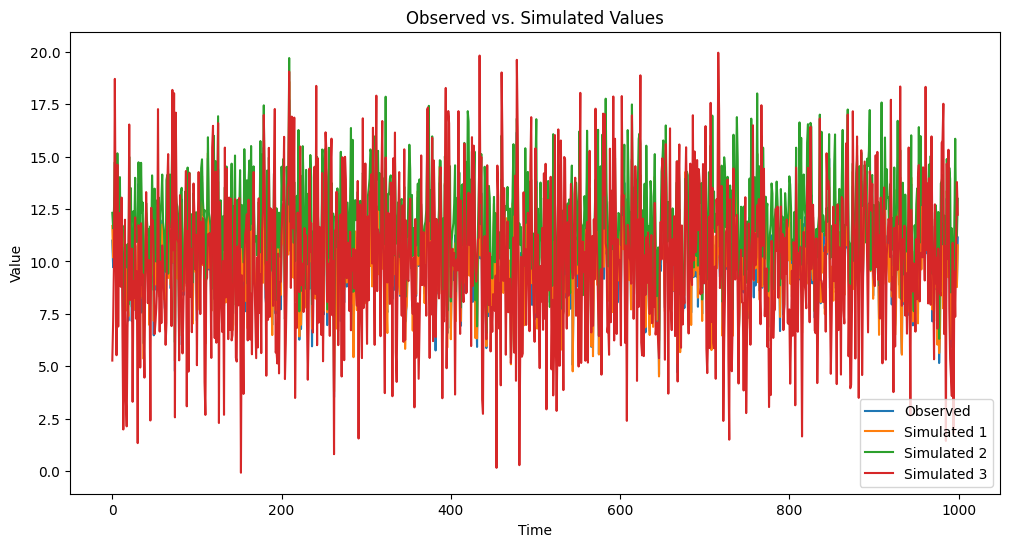

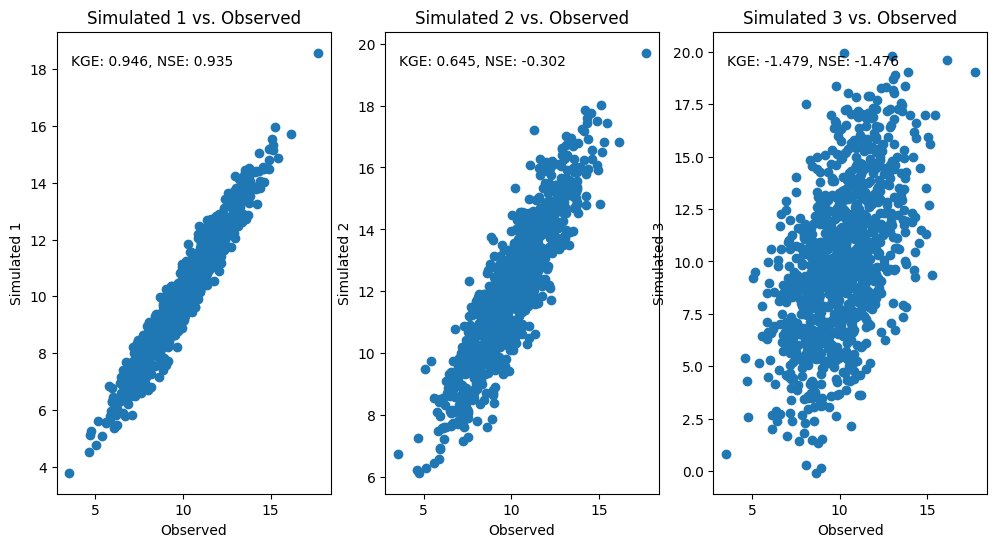

In [10]:
# Plot observed, simulated, and error values
plt.figure(figsize=(12, 6))
plt.plot(obs, label='Observed')
plt.plot(sim_1, label='Simulated 1')
plt.plot(sim_2, label='Simulated 2')
plt.plot(sim_3, label='Simulated 3')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Observed vs. Simulated Values')
plt.show()

# Create scatter plots
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.scatter(obs, sim_1)
plt.xlabel('Observed')
plt.ylabel('Simulated 1')
plt.title('Simulated 1 vs. Observed')
plt.text(0.05, 0.95, f'KGE: {kge_1:.3f}, NSE: {nse_1:.3f}', transform=plt.gca().transAxes, horizontalalignment='left', verticalalignment='top')


plt.subplot(1, 3, 2)
plt.scatter(obs, sim_2)
plt.xlabel('Observed')
plt.ylabel('Simulated 2')
plt.title('Simulated 2 vs. Observed')
plt.text(0.05, 0.95, f'KGE: {kge_2:.3f}, NSE: {nse_2:.3f}', transform=plt.gca().transAxes, horizontalalignment='left', verticalalignment='top')


plt.subplot(1, 3, 3)
plt.scatter(obs, sim_3)
plt.xlabel('Observed')
plt.ylabel('Simulated 3')
plt.title('Simulated 3 vs. Observed')
plt.text(0.05, 0.95, f'KGE: {kge_3:.3f}, NSE: {nse_3:.3f}', transform=plt.gca().transAxes, horizontalalignment='left', verticalalignment='top')


plt.show()

# Decomposiion of NSE

In [12]:
def nse_decompos(fcst,obs):
    r = np.corrcoef(obs, fcst)[0, 1]
    mu_fcst = np.mean(fcst)
    mu_obs = np.mean(obs)
    sigma_fcst = np.std(fcst)
    sigma_obs = np.std(obs)
    A = r**2
    B = (r - sigma_fcst/sigma_obs)**2
    C = ((mu_fcst-mu_obs)/sigma_obs)**2
    NSE = A - B - C
    return NSE, A, B, C


In [13]:
nse_decomp_1 = nse_decompos(sim_1,obs)
nse_decomp_2 = nse_decompos(sim_2,obs)
nse_decomp_3 = nse_decompos(sim_3,obs)

In [14]:
nse_decomp_1

(np.float64(0.9348227314666214),
 np.float64(0.9380008984961962),
 np.float64(0.0028507746628076503),
 np.float64(0.00032739236676702905))

In [15]:
nse_decomp_2

(np.float64(-0.30221318671099406),
 np.float64(0.8022232887044791),
 np.float64(0.05439212357133561),
 np.float64(1.0500443518441376))

In [16]:
nse_decomp_3

(np.float64(-1.4764120126641116),
 np.float64(0.27915332775418217),
 np.float64(1.7547422728738233),
 np.float64(0.0008230675444705412))

In [18]:
nse_1,nse_2,nse_3

(np.float64(0.9348227314666213),
 np.float64(-0.3022131867109932),
 np.float64(-1.4764120126641127))

In [20]:
np.allclose(nse_1,nse_decomp_1[0])

True

In [21]:
np.allclose(nse_2,nse_decomp_2[0])

True

In [22]:
np.allclose(nse_3,nse_decomp_3[0])

True